<a href="https://colab.research.google.com/github/mariahmota/Fundamentos_Computacionais/blob/main/Problema_CSTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

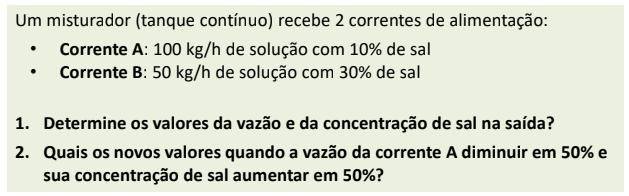

In [ ]:
from dataclasses import dataclass

@dataclass
class CSTR_parametro:
  F: float = 50.0 # L/min
  V: float = 100.0 # L
  k: float = 0.5 # 1/min

def CSTR_modelo(param, Ca_entrada):
  Ca_saida = (param.F*Ca_entrada)/(param.F + param.V*param.k)

  return Ca_saida

def CSTR_series(lista_param, Ca_entrada):
  conc = [Ca_entrada]
  conv = []
  for param in lista_param:
    Ca_saida = CSTR_modelo(param, Ca_entrada)
    conv_local = 1 - Ca_saida/conc[0]
    conc.append(Ca_saida)
    conv.append(conv_local)
    Ca_entrada = Ca_saida

  return conc, conv


In [ ]:
reator1 = CSTR_parametro()
Ca0 = 1.0

Ca1 = CSTR_modelo(reator1, Ca0)
Ca2 = CSTR_modelo(reator1, Ca1)
Ca3 = CSTR_modelo(reator1, Ca2)

print(Ca0, Ca1, Ca2, Ca3)

1.0 0.5 0.25 0.125


In [ ]:
# Parametros do reator
lista_param = 3*[CSTR_parametro()]
Ca0 = 1.0

# Simulação
conc, conv = CSTR_series(lista_param, Ca0)

print(conc)
print(conv)

[1.0, 0.5, 0.25, 0.125]
[0.5, 0.75, 0.875]


In [ ]:
 lista_param2 = [CSTR_parametro(F=50, V=200, k=0.35),
                 CSTR_parametro(F=50, V=100, k=0.35),
                 CSTR_parametro(F=50, V=50, k=3.00)]

# Simulação
conc2, conv2 = CSTR_series(lista_param2, Ca0)

print(conc2)
print(conv2)


[1.0, 0.4166666666666667, 0.2450980392156863, 0.06127450980392157]
[0.5833333333333333, 0.7549019607843137, 0.9387254901960784]
